# HVM Retrieval Analysis

Evaluate whether neural-predicted embeddings recover held-out image identity beyond category. The notebook reports full 90-way retrieval, all-distractor 2-AFC, within-category 2-AFC, cross-category 2-AFC, rank distributions, and nearest-neighbor examples.

## Setup

The notebook uses `scripts/hvm_retrieval_analysis.py` as the backend so the CLI script and notebook stay consistent.

In [7]:
from pathlib import Path
import sys

import pandas as pd
import torch
from IPython.display import display

sys.path.append('.')

from data_utils.hvm_loader import _category_stratified_split, make_hvm_multihead_loader
from scripts.hvm_retrieval_analysis import (
    build_model,
    collect_metrics,
    load_checkpoint_path,
    make_figure,
    predict_loader,
)

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.precision", 3)

## Configuration

Set `NO_CATEGORY = True` for the anchor analysis: neural-only predictions with category conditioning removed.

In [8]:
CHECKPOINT = None  # Path("checkpoints/.../best.pt") or None for the cached best given checkpoint
NO_CATEGORY = True
CAT_MODE = None  # None uses checkpoint args; otherwise "given" or "predict"
SPLIT_SEED = None  # None uses checkpoint args when present, else 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 128
TOPK = [1, 5]
N_NEIGHBORS = 5
N_EXAMPLES = 6
SAVE_RESULTS = False
OUT_DIR = None  # Used only when SAVE_RESULTS is True

DEVICE

'cuda'

## Load Checkpoint And Data

In [9]:
ckpt_path = load_checkpoint_path(CHECKPOINT)
ckpt = torch.load(ckpt_path, weights_only=False, map_location="cpu")
ckpt_args = ckpt.get("args", {})

split_seed = SPLIT_SEED if SPLIT_SEED is not None else int(ckpt_args.get("seed", 42))
cat_mode = CAT_MODE or ckpt_args.get("cat_mode", "given")
area = ckpt_args.get("area") or "all"
neuron_indices = ckpt.get("neuron_indices")

train_loader, _, test_loader = make_hvm_multihead_loader(
    batch_size=BATCH_SIZE,
    seed=split_seed,
    area=area,
    neuron_indices=neuron_indices,
)

sample_neural, _, _ = next(iter(test_loader))
model = build_model(ckpt, n_neurons=sample_neural.shape[1]).to(DEVICE)

print(f"checkpoint: {ckpt_path}")
print(f"cat_mode: {cat_mode} | no_category: {NO_CATEGORY} | split_seed: {split_seed} | device: {DEVICE}")

Loading HVM sessions: 100%|██████████| 10/10 [00:03<00:00,  2.55it/s]


HVM multihead loaders (all monkeys): train=270, val=90, test=90, neurons=2330, time=25, targets=(siglip=1152, siglip_obj=1152, clip_short=768) [stratified by category]
checkpoint: /home/yy3658/NeurObjectGen/checkpoints/multihead_v2/hvm_v2/d64_nh4_nl2_sd512_do0.1_lr0.0003_wd0.01_tn0.02_in0.05_nd0.1_bs128_wsg1.0_wso1.0_wc1.0_uw0.1_nw0.1_nt0.07_cmgiven/best.pt
cat_mode: given | no_category: True | split_seed: 42 | device: cuda


/home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## Run Retrieval Metrics

In [10]:
preds, targets, cats = predict_loader(
    model,
    test_loader,
    device=torch.device(DEVICE),
    cat_mode=cat_mode,
    no_category=NO_CATEGORY,
)

metrics_df, ranks_df, nn_df = collect_metrics(preds, targets, cats, train_loader, TOPK)
_, _, test_indices = _category_stratified_split(split_seed)

keep_cols = [
    "representation",
    "target_space",
    "top1",
    "top5",
    "mean_rank",
    "median_rank",
    "2afc_all",
    "2afc_within_category",
    "2afc_cross_category",
]
display(metrics_df[keep_cols])

,representation,target_space,top1,top5,mean_rank,median_rank,2afc_all,2afc_within_category,2afc_cross_category
0,Global SigLIP pred,siglip,0.078,0.278,23.556,14.0,0.747,0.712,0.750
1,Object SigLIP pred,siglip_obj,0.044,0.189,31.400,27.0,0.658,0.599,0.664
2,CLIP pred,clip_short,0.022,0.122,31.733,26.0,0.655,0.500,0.670
3,Global SigLIP pred shuffled,siglip,0.011,0.078,44.056,41.0,0.516,0.536,0.514
4,Object SigLIP pred shuffled,siglip_obj,0.011,0.078,47.011,48.0,0.483,0.501,0.481
5,CLIP pred shuffled,clip_short,0.000,0.033,45.522,44.0,0.500,0.500,0.500
6,siglip category-centroid baseline,siglip,0.111,0.533,6.867,5.0,0.934,0.500,0.977
7,siglip_obj category-centroid baseline,siglip_obj,0.111,0.556,6.133,5.0,0.942,0.500,0.986
8,clip_short category-centroid baseline,clip_short,0.111,0.556,5.000,5.0,0.955,0.500,1.000


## Optional Save

In [11]:
if SAVE_RESULTS:
    import json

    out_dir = Path(OUT_DIR) if OUT_DIR is not None else ckpt_path.parent / "retrieval_analysis"
    out_dir.mkdir(parents=True, exist_ok=True)

    metrics_df.to_csv(out_dir / "retrieval_metrics.csv", index=False)
    ranks_df.to_csv(out_dir / "retrieval_ranks.csv", index=False)
    nn_df.to_csv(out_dir / "nearest_neighbors.csv", index=False)

    with open(out_dir / "retrieval_metrics.json", "w") as f:
        json.dump(
            {
                "checkpoint": str(ckpt_path),
                "cat_mode": cat_mode,
                "no_category": NO_CATEGORY,
                "split_seed": split_seed,
                "metrics": metrics_df.to_dict(orient="records"),
            },
            f,
            indent=2,
        )
    print(f"Wrote retrieval analysis to {out_dir}")
else:
    print("SAVE_RESULTS is False; no files were written.")

SAVE_RESULTS is False; no files were written.


## Figure 1

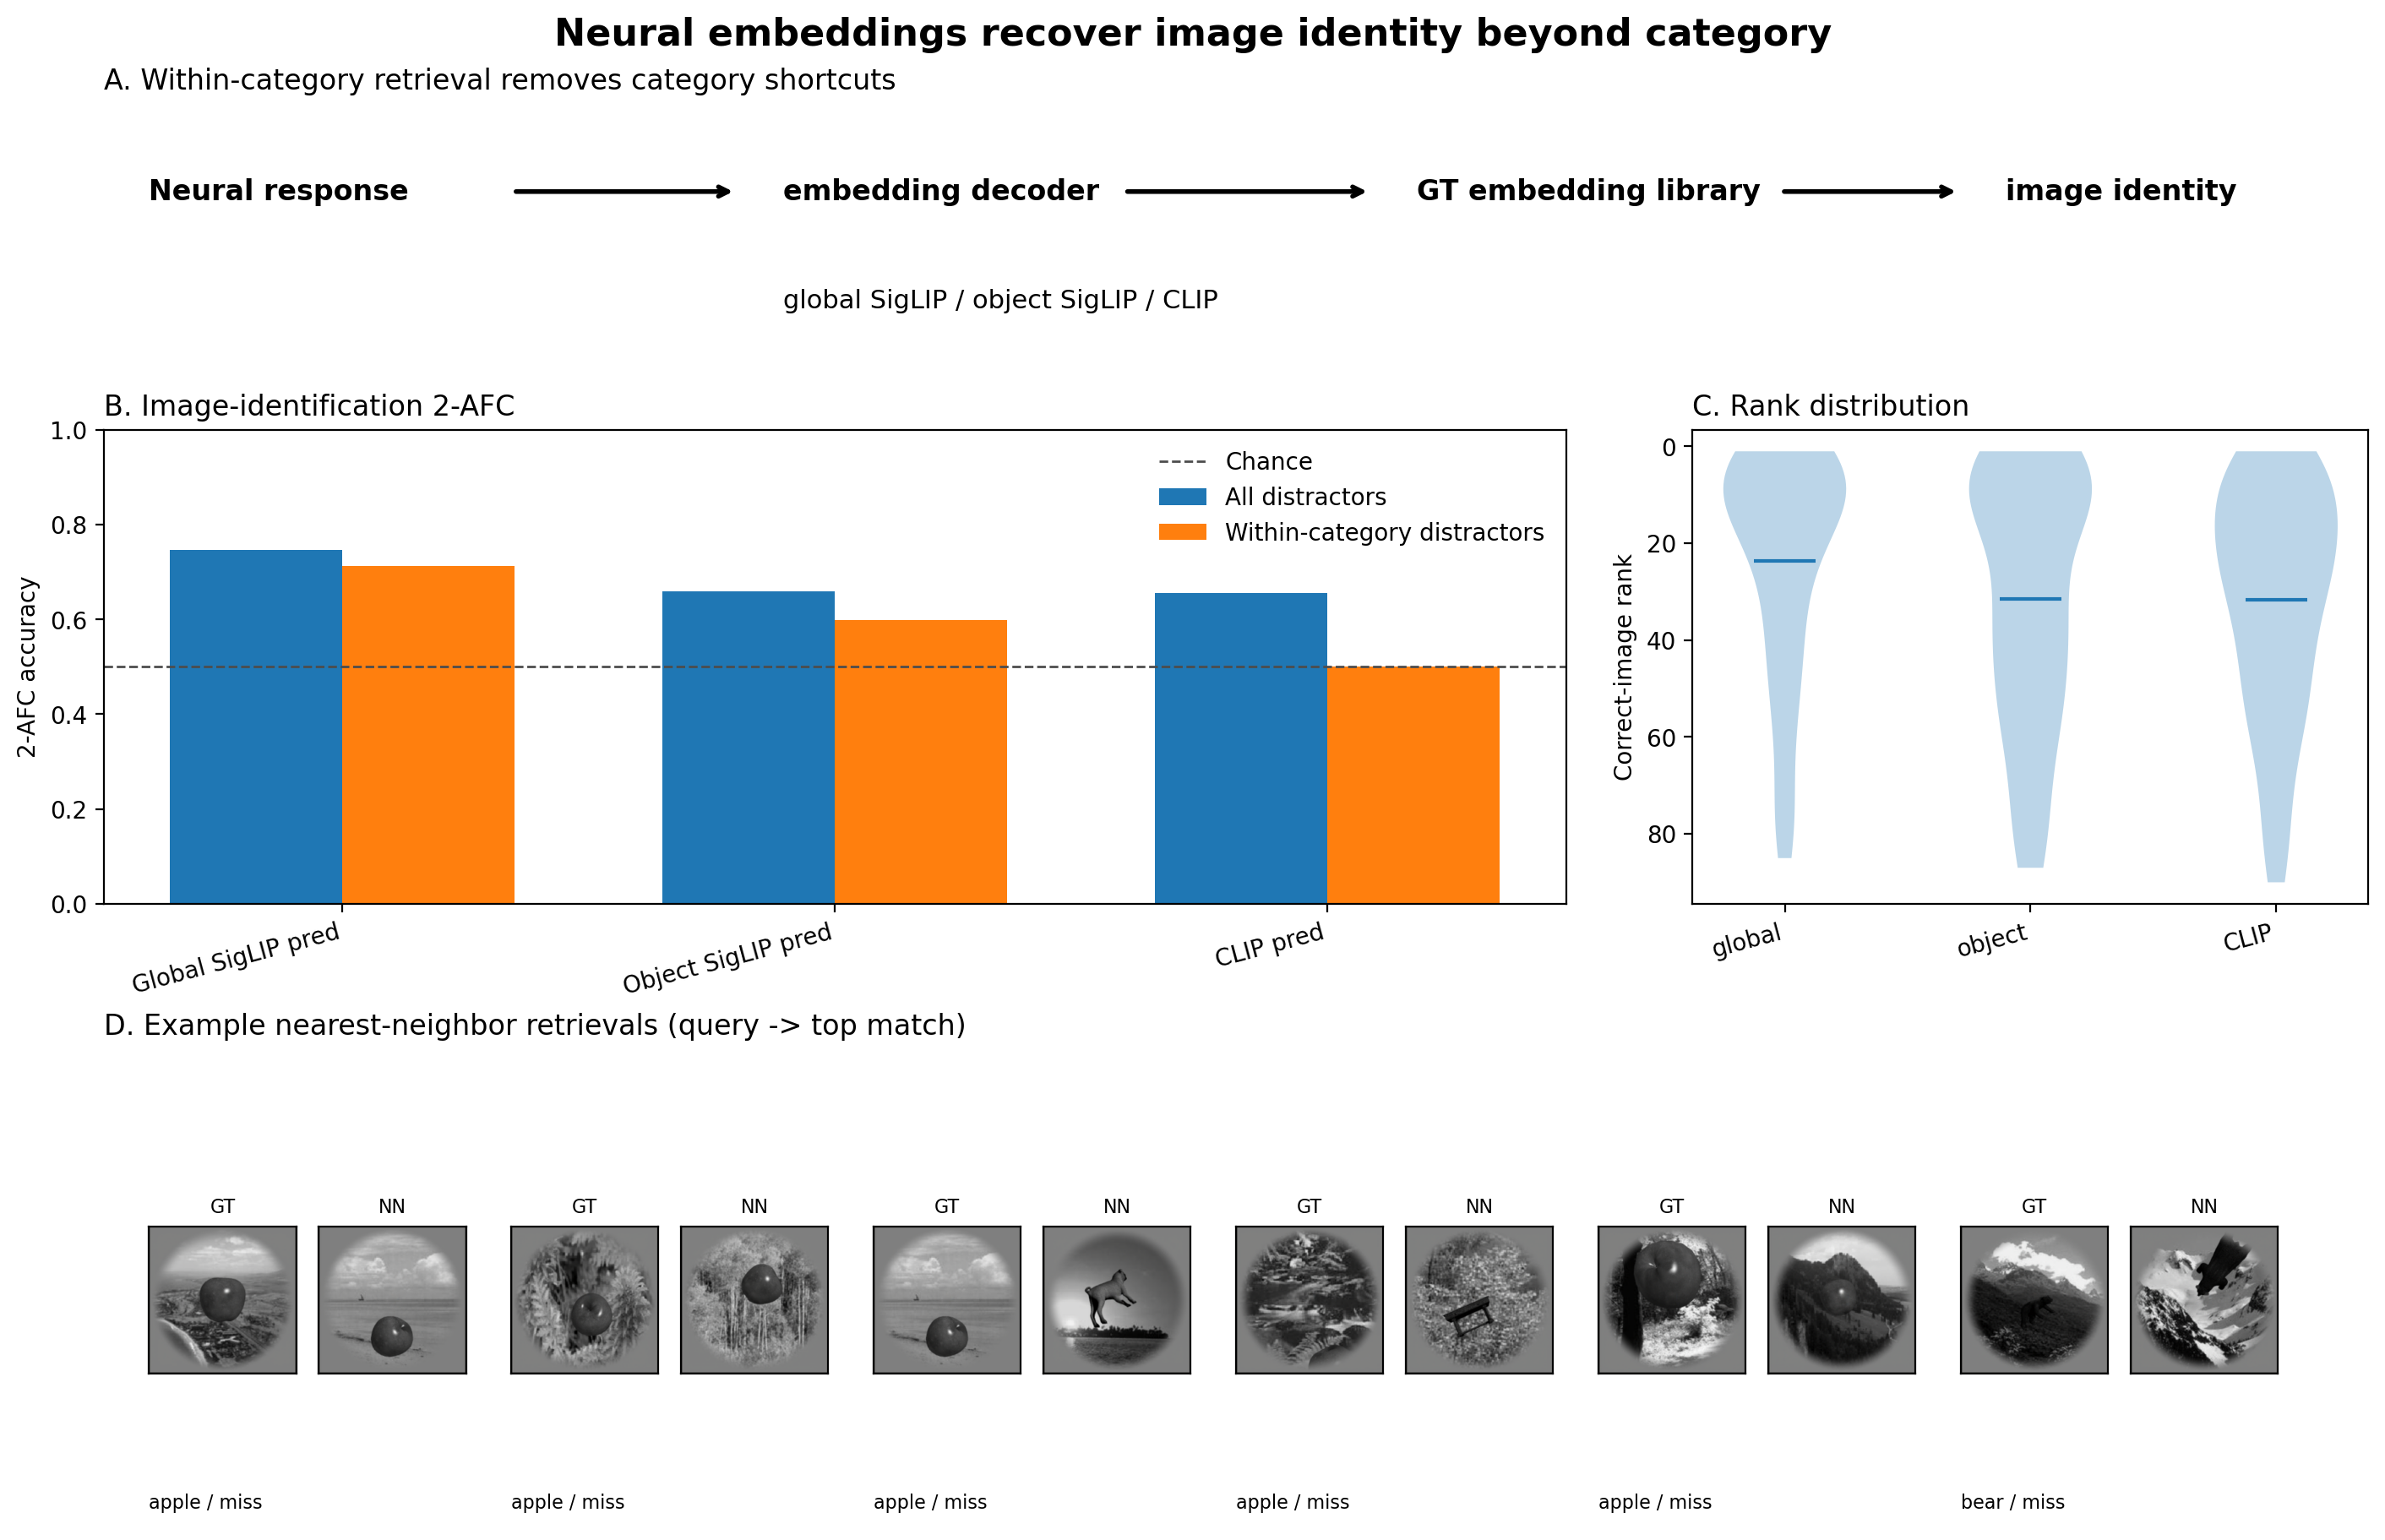

In [12]:
figure = make_figure(
    metrics_df,
    ranks_df,
    nn_df[nn_df["neighbor_rank"] <= N_NEIGHBORS],
    cats,
    test_indices,
    None,
    n_examples=N_EXAMPLES,
)

display(figure)